# Training the TCR-pMHC binding strength prediction model

In [27]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import numpy as np

from catboost import CatBoostClassifier, Pool, metrics, cv
from sklearn.metrics import accuracy_score

In [13]:
# get the data
df_positive = pd.read_excel('~/Desktop/tcrpmhcbinding/positive_tcr_binding_data.xlsx')
df_negative = pd.read_excel('~/Desktop/tcrpmhcbinding/negative_tcr_binding_data.xlsx')
df_negative = df_negative.rename(columns={'Binding': 'Binding_Strength'})

In [3]:
df_negative2 = df_negative[0:81000] # We could intuit this automatically but this is the size of df_positive so we get equal pos/neg samples
full_dataset = pd.concat([df_positive,df_negative2])

In [14]:
# Split into X and y
X = full_dataset.loc[:,['CDR3','MHC_A','Epitope']]
y = full_dataset.loc[:,'Binding_Strength']

In [15]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42) # Update size later?
categorical_features_indices = np.where(X.dtypes != float)[0]



In [16]:
#example model
model = CatBoostClassifier(
    custom_metric=[metrics.Accuracy(),metrics.Precision(),metrics.Recall(),metrics.F1()],
    random_seed=42,
    logging_level='Silent',
    train_dir='/Users/PCHANSKY/Desktop/tcrpmhcbinding/train_dir'
)

#Training the Model

model.fit(
    X_train, y_train,
    cat_features=categorical_features_indices,
    eval_set=(X_test, y_test),
    plot=True
);

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

In [17]:
#Cross Val
cv_params = model.get_params()
cv_params.update({
    'loss_function': metrics.Logloss() #\
})

cv_data = cv(
    Pool(X, y, cat_features=categorical_features_indices),
    cv_params,
    plot=True
)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

In [ ]:
CatBoostClassifier.save_model(model,fname="catboost_model.cbm",
           format="cbm",
           export_parameters=None,
           pool=None) # Check location for save path !

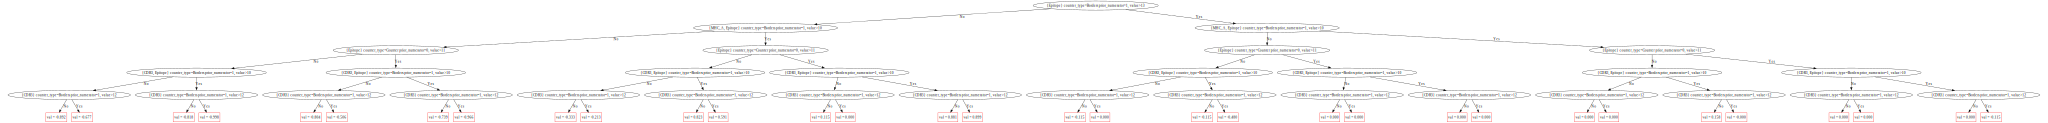

In [28]:
pool = Pool(X, y, cat_features=categorical_features_indices, feature_names=list(X.columns))

model.plot_tree(
    tree_idx=0,
    pool=pool
)

([<matplotlib.axis.XTick at 0x17cc0a790>,
 [Text(1, 0, 'Accuracy'),
  Text(2, 0, 'Precision'),
  Text(3, 0, 'Recall'),
  Text(4, 0, 'F1')])

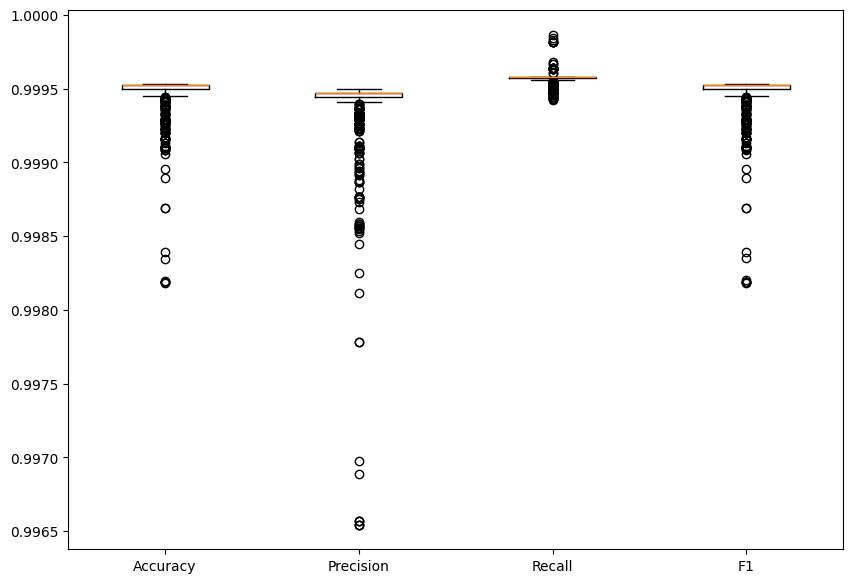

In [29]:

eval_data = cv_data.loc[:,['test-Accuracy-mean','test-Precision-mean','test-Recall-mean','test-F1-mean']]


fig = plt.figure(figsize =(10, 7))

# Creating plot
plt.boxplot(eval_data)
# x-axis labels
plt.xticks([1, 2, 3,4], ['Accuracy', 'Precision', 'Recall','F1'])